In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
device = 'cuda'

In [4]:
# import os

# # Assumes wget is available! Otherwise, use curl or download manually
# # from https://dspace.mit.edu/handle/1721.1/105492
# os.system("wget https://dspace.mit.edu/bitstream/handle/1721.1/105492/fermi_data.tar.gz?sequence=5");
# os.system("tar -xvf fermi_data.tar.gz?sequence=5");
# os.system("rm -r fermi_data.tar.gz*");

In [5]:
import skimage

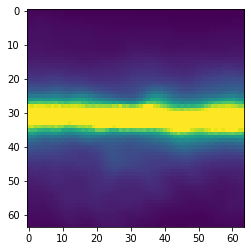

In [6]:
import healpy as hp
from functools import partial

nside= 128

dif_hp = np.load("fermi_data/template_dif.npy")

# Get the cutout via a cartesian projection
lonra = [-10, 10]
latra = [-10, 10]

proj = hp.projector.CartesianProj(lonra=lonra, latra=latra,
    coord='G')

dif_cart = proj.projmap(dif_hp, vec2pix_func=partial(hp.vec2pix, nside))

size = (64, 64)
dif_cart = skimage.transform.resize(dif_cart, size, order=3)

plt.imshow(dif_cart, vmax=10)

In [7]:
from scipy.stats import binned_statistic_2d
from astropy.convolution import convolve, Gaussian2DKernel
from scipy.stats import norm

t_min = -1  # Coordinate boundaries
t_max = 1
n_t = 64  # Number of pixels
counts_min = 150  # Minimum and maximum counts emitted by each PS
counts_max = 250
fwhm_psf = 0.1  # FWHM of Gaussian PSF

# Pixel binning
pixel_size = (t_max - t_min) / n_t
bins = np.linspace(t_min, t_max, n_t + 1)

# PSF stuff
sigma_psf = fwhm_psf / 2 ** 1.5 * np.sqrt(np.log(2))  # Convert FWHM to standard deviation
kernel = Gaussian2DKernel(x_stddev=1.0 * sigma_psf / pixel_size)

def simulate(plot=False, poiss_fluctuate=True):
    
    mu_iso = 5  # np.random.uniform(0, 10)
    
    mu_ps_iso = np.random.uniform(100, 150)
    n_ps_iso = np.random.poisson(mu_ps_iso)
    
    # Draw position of PSs and their counts
    z_x_iso = np.random.uniform(t_min, t_max, size=(2, n_ps_iso))
    z_c_iso = np.random.uniform(counts_min, counts_max, n_ps_iso)
    
    mu_ps_csp = np.random.uniform(0, 10)
    n_ps_csp = 0  # np.random.poisson(mu_ps_csp)
    
    # Draw position of PSs and their counts
    z_x_csp = norm.rvs(loc=0, scale=0.5, size=(2, n_ps_csp)) 
    z_c_csp = np.random.uniform(counts_min, counts_max, n_ps_csp)
    
    mu_iso_map = mu_iso * np.ones((n_t, n_t))

    if n_ps_iso > 0:
        mu_signal_iso = binned_statistic_2d(x=z_x_iso[0], y=z_x_iso[1], values=z_c_iso, statistic='sum', bins=bins).statistic
    else:
        mu_signal_iso = np.zeros_like(mu_iso_map)
        
    if n_ps_csp > 0:
        mu_signal_csp = binned_statistic_2d(x=z_x_csp[0], y=z_x_csp[1], values=z_c_csp, statistic='sum', bins=bins).statistic
    else:
        mu_signal_csp =  np.zeros_like(mu_iso_map)
        
    counts_binned = (mu_iso_map + 5 * dif_cart + convolve(mu_signal_iso, kernel) + convolve(mu_signal_csp, kernel))

    if poiss_fluctuate:
        counts_binned = np.random.poisson(counts_binned)

    if plot:
        plt.imshow(counts_binned)
    
    return mu_ps_iso, counts_binned

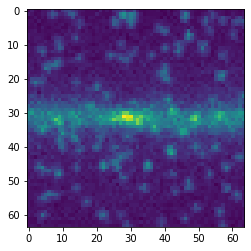

In [8]:
_, x = simulate(plot=True)

In [9]:
from tqdm.notebook import tqdm
simulations = [simulate() for _ in tqdm(range(5000))]

  0%|          | 0/5000 [00:00<?, ?it/s]

In [10]:
from operator import itemgetter

x = list(map(itemgetter(1), simulations))
mu_ps_iso = list(map(itemgetter(0), simulations))

In [11]:
x = torch.Tensor(np.array(x)).unsqueeze(1).to(torch.int32)
y = torch.Tensor(np.array([mu_ps_iso])).T

In [12]:
# x_std = x.std(axis=0)
# x_mean = x.mean()
# x = (x - x_mean) / x_std

y_std = y.std(axis=0)
y_mean = y.mean(axis=0)
y = (y - y_mean) / y_std

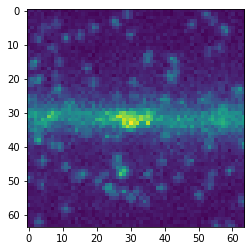

In [13]:
plt.imshow(x[0,0])

In [10]:
from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [15]:
val_fraction = 0.1
n_samples_val = int(val_fraction * len(x))

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=8, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=8, shuffle=False)

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/utils/data/dataloader.py:478: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [16]:
import sys
sys.path.append("../")

from models.flow_utils import VariationalDequantization, CouplingLayer, GatedConvNet, SplitFlow, SqueezeFlow, create_channel_mask, create_checkerboard_mask
from models.flows import ImageFlow

In [17]:
# def create_simple_flow():
#     flow_layers = []
    
#     for i in range(4):
#         flow_layers += [CouplingLayer(network=GatedConvNet(c_in=1, c_hidden=32),
#                                       mask=create_checkerboard_mask(h=64, w=64, invert=(i%2==1)),
#                                       c_in=1)]

#     flow_model = ImageFlow(flow_layers).to(device)
#     return flow_model


In [18]:
# model = create_simple_flow()

In [19]:
def create_multiscale_flow():
    flow_layers = []

    vardeq_layers = [CouplingLayer(network=GatedConvNet(c_in=2, c_out=2, c_hidden=16),
                                   mask=create_checkerboard_mask(h=64, w=64, invert=(i%2==1)),
                                   c_in=1) for i in range(4)]
    flow_layers += [VariationalDequantization(vardeq_layers)]

    flow_layers += [CouplingLayer(network=GatedConvNet(c_in=1, c_hidden=32),
                                  mask=create_checkerboard_mask(h=64, w=64, invert=(i%2==1)),
                                  c_in=1) for i in range(2)]
    flow_layers += [SqueezeFlow()]
    for i in range(2):
        flow_layers += [CouplingLayer(network=GatedConvNet(c_in=4, c_hidden=48),
                                      mask=create_channel_mask(c_in=4, invert=(i%2==1)),
                                      c_in=4)]
    flow_layers += [SplitFlow(),
                    SqueezeFlow()]
    for i in range(4):
        flow_layers += [CouplingLayer(network=GatedConvNet(c_in=8, c_hidden=64),
                                      mask=create_channel_mask(c_in=8, invert=(i%2==1)),
                                      c_in=8)]

    flow_model = ImageFlow(flow_layers).to(device)
    return flow_model


In [20]:
model = create_multiscale_flow()

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [49]:
checkpoint_callback = ModelCheckpoint(monitor="val_bpd")
early_stop_callback = EarlyStopping(monitor='val_bpd', patience=8)        
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer = pl.Trainer(max_epochs=20, gpus=1, gradient_clip_val=1., callbacks=[checkpoint_callback, early_stop_callback, lr_monitor])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
# model.load_from_checkpoint(checkpoint_callback.best_model_path);

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Set SLURM handle signals.

  | Name  | Type       | Params
-------------------------------------
0 | flows | ModuleList | 1.1 M 
-------------------------------------
1.1 M     Trainable params
0         Non-trainable params
1.1 M     Total params
4.248     Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Training: -1it [00:00, ?it/s]

[W accumulate_grad.h:185] Warning: grad and param do not obey the gradient layout contract. This is not an error, but may impair performance.
grad.sizes() = [128, 128, 1, 1], strides() = [128, 1, 1, 1]
param.sizes() = [128, 128, 1, 1], strides() = [128, 1, 128, 128] (function operator())


Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [50]:
model.to('cuda');

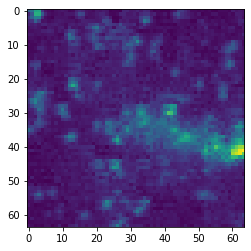

In [134]:
x_samp = model.sample(img_shape=[16,1,16,16])[0,0].cpu().detach().numpy()
plt.imshow(x_samp)

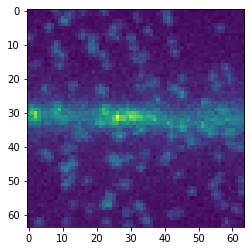

In [125]:
ii = 10

# Original image
plt.imshow(x[ii,0])

In [119]:
# Encode into base distribution
z = model.encode(x[:16].to('cuda'))

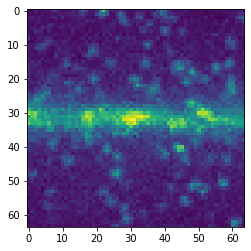

In [65]:
# Run flow in forward direction
x_samp = model.sample(img_shape=[16,1,16,16], z_init=z[0])
plt.imshow(x_samp[ii,0].cpu().detach().numpy())

Text(0.5, 1.0, 'residual')

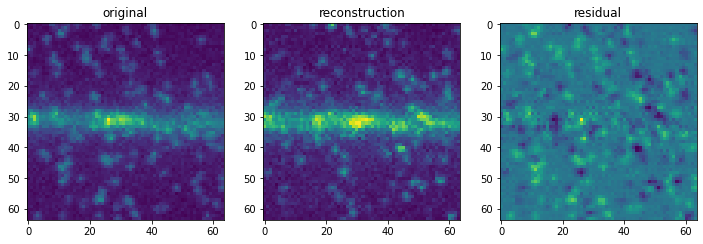

In [89]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

ax[0].imshow(x[ii,0])
ax[0].set_title("original")

ax[1].imshow(x_samp[ii,0].cpu().detach().numpy())
ax[1].set_title("reconstruction")

ax[2].imshow(x[ii,0] - x_samp[ii,0].cpu().detach().numpy())
ax[2].set_title("residual")


In [87]:
z = model.encode(x[:16].to('cuda'))[0]
ldj = torch.zeros(16, device=device)

for flow in reversed(model.flows):
    z, ldj = flow(z, ldj, reverse=True)

In [112]:
x_test = torch.Tensor([simulate(plot=False)[1] for _ in range(16)]).unsqueeze(1)
x_test.shape

torch.Size([16, 1, 64, 64])

In [116]:
model._get_likelihood(x[:16].to('cuda'), return_ll=True).mean()

tensor(-13084.5410, device='cuda:0', grad_fn=<MeanBackward0>)

In [117]:
model._get_likelihood(x_test.to('cuda'), return_ll=True).mean()

tensor(-13061.1816, device='cuda:0', grad_fn=<MeanBackward0>)

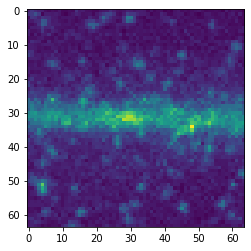

In [88]:
plt.imshow(z[0,0].cpu().detach().numpy())

## Glow

In [11]:
import numpy as np
import normflow as nf

In [52]:
# Set up model

# Define flows
L = 3
K = 16
torch.manual_seed(0)

input_shape = (1, 64, 64)
n_dims = np.prod(input_shape)
channels = 1
hidden_channels = 256
split_mode = 'channel'
scale = True

# Set up flows, distributions and merge operations
q0 = []
merges = []
flows = []
for i in range(L):
    flows_ = []
    for j in range(K):
        flows_ += [nf.flows.GlowBlock(channels * 2 ** (L + 1 - i), hidden_channels,
                                     split_mode=split_mode, scale=scale)]
    flows_ += [nf.flows.Squeeze()]
    flows += [flows_]
    latent_shape = (input_shape[0] * 2 ** (L - i), input_shape[1] // 2 ** (L - i), 
                    input_shape[2] // 2 ** (L - i))
    if i > 0:
        merges += [nf.flows.Merge()]
        latent_shape = (input_shape[0] * 2 ** (L - i), input_shape[1] // 2 ** (L - i), 
                        input_shape[2] // 2 ** (L - i))
    else:
        latent_shape = (input_shape[0] * 2 ** (L + 1), input_shape[1] // 2 ** L, 
                        input_shape[2] // 2 ** L)
    q0 += [nf.distributions.DiagGaussian(latent_shape)]


# Construct flow model
model = nf.MultiscaleFlow(q0, flows, merges)

In [53]:
model.class_cond = False

In [56]:
model.to('cuda')
model.forward_kld(x[:16].to('cuda'))

tensor(5728.2500, device='cuda:0', grad_fn=<NegBackward0>)

In [63]:
class Glow(pl.LightningModule):

    def __init__(self):
        """
        Inputs:
            flows - A list of flows (each a nn.Module) that should be applied on the images.
        """
        super().__init__()
        self.flows = nf.MultiscaleFlow(q0, flows, merges)
        self.flows.class_cond = False

    def log_prob(self, x):
        """
        Given a batch of images, return the likelihood of those.
        If return_ll is True, this function returns the log likelihood of the input.
        Otherwise, the ouptut metric is bits per dimension (scaled negative log likelihood)
        """
        return self.flows.forward_kld(x)

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=3e-4, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)
        
        return {"optimizer": optimizer, 
                    "lr_scheduler": {
                    "scheduler": scheduler,
                    "interval": "epoch",
                    "monitor": "val_loss",
                    "frequency": 1}
                }
    def training_step(self, batch, batch_idx):
        # Normalizing flows are trained by maximum likelihood => return bpd
        loss = self.log_prob(batch[0])
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self.log_prob(batch[0])
        self.log('val_loss', loss)

In [64]:
from operator import itemgetter

x = list(map(itemgetter(1), simulations))
mu_ps_iso = list(map(itemgetter(0), simulations))

In [65]:
x = torch.Tensor(np.array(x)).unsqueeze(1)#.to(torch.int32)
y = torch.Tensor(np.array([mu_ps_iso])).T

In [66]:
x_std = x.std(axis=0)
x_mean = x.mean()
x = (x - x_mean) / x_std

y_std = y.std(axis=0)
y_mean = y.mean(axis=0)
y = (y - y_mean) / y_std

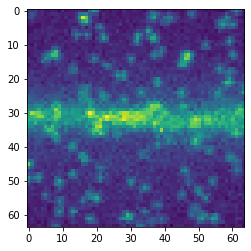

In [67]:
plt.imshow(x[0,0])

In [68]:
model.log_prob(x[:64].to('cuda'))

tensor(5725.9492, device='cuda:0', grad_fn=<NegBackward0>)

In [69]:
val_fraction = 0.1
n_samples_val = int(val_fraction * len(x))

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=8, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=8, shuffle=False)

In [70]:
model = Glow()

In [99]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
early_stop_callback = EarlyStopping(monitor='val_loss', patience=8)        
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer = pl.Trainer(max_epochs=10, gpus=1, gradient_clip_val=1., callbacks=[checkpoint_callback, early_stop_callback, lr_monitor])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
# model.load_from_checkpoint(checkpoint_callback.best_model_path);

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Set SLURM handle signals.

  | Name  | Type           | Params
-----------------------------------------
0 | flows | MultiscaleFlow | 4.7 M 
-----------------------------------------
4.7 M     Trainable params
0         Non-trainable params
4.7 M     Total params
18.957    Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/utils/data/dataloader.py:478: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

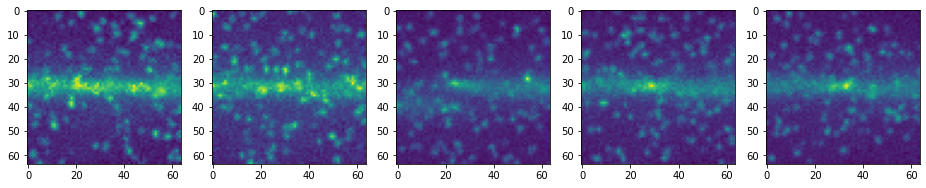

In [107]:
fig, axs = plt.subplots(1, 5, figsize=(16,4))

for ax in axs:
    ax.imshow(model.flows.sample()[0][0,0].detach().numpy())

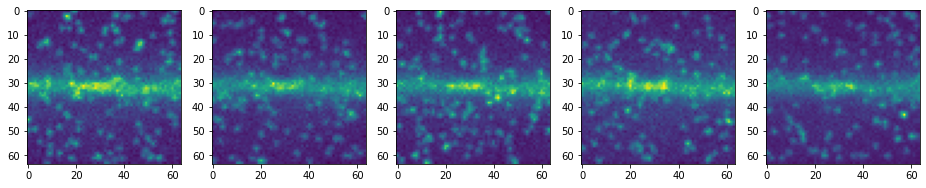

In [108]:
fig, axs = plt.subplots(1, 5, figsize=(16, 4))

for i, ax in enumerate(axs):
    ax.imshow(x[i,0].detach().numpy())